##1. Importar las librerías necesarias para el análisis de datos

*   Pandas
*   Matplotlib
*   Seaborn















In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


##2. Carga y procesamiento de datos

Se carga el archivo CSV con datos obtenidos de radiación solar del 2010 al 2024.  
Debido a que el archivo contiene información adicional en las primeras filas, se omiten.
Luego, los datos son separados manualmente en columnas.

In [40]:


df = pd.read_csv(
    "solar_paraguay_limpio.csv",
    skiprows=15,
   header=None
)
#df = pd.read_csv("solar_paraguay_limpio.csv", skiprows=15, sep=",")

df = df[0].str.split(",", expand=True)

df.columns = ["YEAR","MO","DY","ALLSKY","CLRSKY","DNI"]

## 3. Exploración inicial

Se analiza la estructura del dataset, incluyendo dimensiones, tipos de datos y estadísticas descriptivas.

In [41]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print(df.head())

(5476, 6)
Index(['YEAR', 'MO', 'DY', 'ALLSKY', 'CLRSKY', 'DNI'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5476 entries, 0 to 5475
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   YEAR    5476 non-null   object
 1   MO      5476 non-null   object
 2   DY      5476 non-null   object
 3   ALLSKY  5476 non-null   object
 4   CLRSKY  5476 non-null   object
 5   DNI     5476 non-null   object
dtypes: object(6)
memory usage: 256.8+ KB
None
        YEAR    MO    DY  ALLSKY CLRSKY     DNI
count   5476  5476  5476    5476   5476    5476
unique    15    12    31    5070   4870    5128
top     2012     3     4  3.8146  8.351  0.2849
freq     366   465   180       4      4       4
   YEAR MO DY  ALLSKY  CLRSKY     DNI
0  2010  1  4  7.1947  8.0268   5.473
1  2010  1  5   7.891  8.1706  7.7059
2  2010  1  6  6.5374  8.1569   3.959
3  2010  1  7  6.8851  8.1192  4.6481
4  2010  1  8  6.7834  8.1912  3.5434


## 4. Limpieza de datos

Se convierten las columnas de radiación a valores numéricos.  
Los valores no válidos se transforman en NaN para evitar errores en cálculos.

In [42]:
df["ALLSKY"] = pd.to_numeric(df["ALLSKY"], errors="coerce")
df["CLRSKY"] = pd.to_numeric(df["CLRSKY"], errors="coerce")
df["DNI"] = pd.to_numeric(df["DNI"], errors="coerce")

##5. Creación de variables de tiempo

Se renombran columnas para facilitar su uso y se crea una columna de tipo fecha.

In [43]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    "YEAR": "year",
    "MO": "month",
    "DY": "day"
})
df["DATE"] = pd.to_datetime(df[["year","month","day"]])

df["month"] = df["DATE"].dt.month

##6. Estimación de energía generada

Se calcula la energía diaria generada por un sistema solar de 1 kW.

Se utiliza un performance ratio de 0.75, que representa pérdidas del sistema.

 Se realiza un análisis de generación
para calcular la energía total anual y el promedio mensual.

In [44]:

potencia_kw = 1
performance_ratio = 0.75

df["energia_kwh_dia"] = df["ALLSKY"] * potencia_kw * performance_ratio

energia_anual = df["energia_kwh_dia"].sum()

print("Producción anual estimada (kWh):", energia_anual)

energia_mensual = df.groupby("month")["energia_kwh_dia"].mean()
print(energia_mensual )


Producción anual estimada (kWh): 20353.06725
month
1     5.122126
2     4.699468
3     4.060529
4     3.294541
5     2.446509
6     2.122699
7     2.398521
8     2.992282
9     3.470617
10    4.115027
11    4.814976
12    5.122176
Name: energia_kwh_dia, dtype: float64


##7. Visualización de generación mensual

Se representa gráficamente la energía promedio generada por mes.

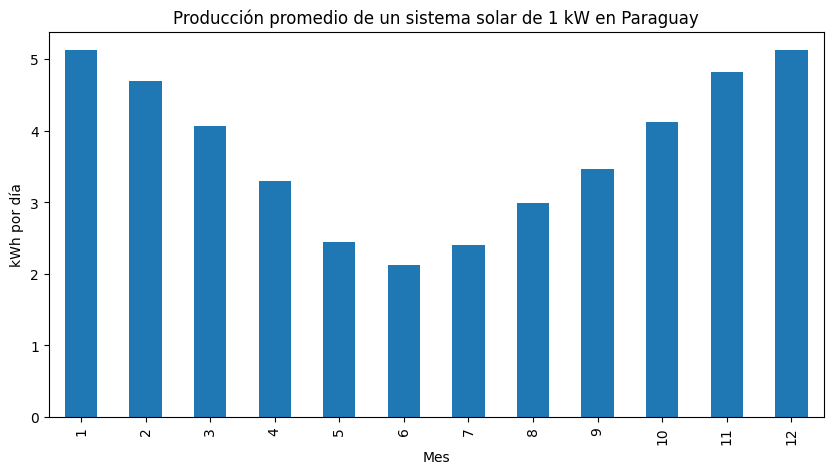

In [45]:
import os

energia_mensual.plot(kind="bar", figsize=(10,5))
plt.title("Producción promedio de un sistema solar de 1 kW en Paraguay")
plt.xlabel("Mes")
plt.ylabel("kWh por día")

# Create the 'images' directory if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')

plt.savefig("images/generacion_solar.png", dpi=300, bbox_inches="tight")
plt.show()

Los resultados indican que un sistema solar fotovoltaico de 1 kW en Paraguay podría generar aproximadamente entre 1400 y 1800 kWh anuales. La mayor producción se concentra entre los meses de octubre y marzo, coincidiendo con los meses de mayor radiación solar.

##8. Análisis de radiación solar

Se analiza la radiación promedio mensual para identificar variaciones estacionales.



month
1     6.829502
2     6.265958
3     5.414039
4     4.392721
5     3.262012
6     2.830265
7     3.198028
8     3.989709
9     4.627490
10    5.486702
11    6.419968
12    6.829568
Name: ALLSKY, dtype: float64


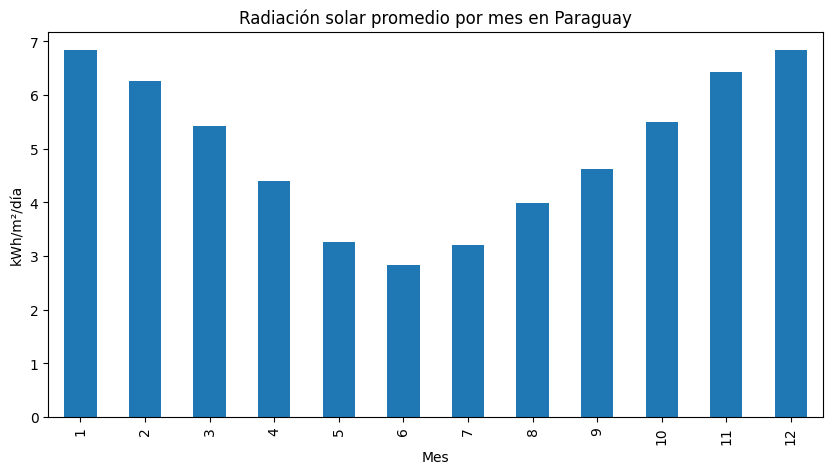

In [46]:

radiacion_mensual = df.groupby("month")["ALLSKY"].mean()
print(radiacion_mensual)

radiacion_mensual.plot(kind="bar", figsize=(10,5))
plt.title("Radiación solar promedio por mes en Paraguay")
plt.xlabel("Mes")
plt.ylabel("kWh/m²/día")
plt.savefig("images/radiacion_mensual.png", dpi=300, bbox_inches="tight")
plt.show()

El análisis de radiación solar promedio mensual en Paraguay para el período 2010–2024 muestra una clara estacionalidad. Los valores máximos se registran entre octubre y marzo, alcanzando aproximadamente 6–7 kWh/m²/día, mientras que los mínimos ocurren entre mayo y julio con valores cercanos a 3 kWh/m²/día.

Estos resultados evidencian un alto potencial para la generación de energía solar fotovoltaica en Paraguay, especialmente durante los meses de primavera y verano.

##9. Escenario Residencial

Se simula un sistema de mayor capacidad (3 kW) para un escenario residencial.

In [47]:
df["energia_3kw"] = df["energia_kwh_dia"] * 3
energia_mensual_3kw = df.groupby("month")["energia_3kw"].mean()

print(energia_mensual_3kw)

month
1     15.366379
2     14.098405
3     12.181588
4      9.883622
5      7.339528
6      6.368096
7      7.195564
8      8.976845
9     10.411851
10    12.345080
11    14.444928
12    15.366528
Name: energia_3kw, dtype: float64


Para el escenario residencial se asumió un consumo mensual de 300 kWh, representativo de una vivienda promedio, con el objetivo de comparar dicho consumo con la generación estimada de un sistema fotovoltaico residencial en Paraguay.

##10. Producción mensual total

Se calcula la energía total generada por mes considerando cada año.

In [48]:

df["year_month"] = df["DATE"].dt.to_period("M")

energia_real = df.groupby("year_month")["energia_3kw"].sum()

print(energia_real.head())

year_month
2010-01    442.609875
2010-02    383.144400
2010-03    403.200675
2010-04    300.572775
2010-05    218.008800
Freq: M, Name: energia_3kw, dtype: float64


##11. Promedio mensual

Se obtiene el promedio de generación mensual a lo largo del tiempo.

In [49]:

energia_promedio_mes = energia_real.groupby(energia_real.index.month).mean()

print(energia_promedio_mes)

year_month
1     473.284485
2     398.514915
3     377.629215
4     296.508675
5     227.525370
6     191.042880
7     223.062480
8     278.282205
9     312.355545
10    382.697475
11    433.347825
12    476.362380
Name: energia_3kw, dtype: float64


##12. Comparación con consumo

Se compara la generación con un consumo promedio de 300 kWh mensuales.

Interpretación del balance:

balance > 0 entonces el sistema solar genera más de lo que consume la casa

balance < 0 entonces la generación no alcanza y se necesita energía de la red

balance = 0 entonces cobertura exacta

In [50]:

consumo_mensual = 300

balance = energia_promedio_mes - consumo_mensual

print(balance)

year_month
1     173.284485
2      98.514915
3      77.629215
4      -3.491325
5     -72.474630
6    -108.957120
7     -76.937520
8     -21.717795
9      12.355545
10     82.697475
11    133.347825
12    176.362380
Name: energia_3kw, dtype: float64


Calculamos:

La energía mensual generada por un sistema solar de 3 kW

El promedio de esa generación por mes calendario

La diferencia contra un consumo fijo de 300 kWh/mes

Así respondemos a las siguientes interrogantes:

¿En qué meses la vivienda cubriría todo su consumo?

¿En qué meses necesitaría apoyo de la red?

¿Hay excedente o déficit mensual?

##13. Modelo tarifario

Se implementa una función de tarifa eléctrica basada en consumo escalonado.

In [51]:

def tarifa_residencial_142(consumo_kwh):
    if consumo_kwh <= 50:
        return 311.55
    elif consumo_kwh <= 150:
        return 349.89
    elif consumo_kwh <= 300:
        return 365.45
    elif consumo_kwh <= 500:
        return 403.82
    elif consumo_kwh <= 1000:
        return 420.27
    else:
        return 435.51

def factura_residencial_142(consumo_kwh):
    return consumo_kwh * tarifa_residencial_142(consumo_kwh)

##14. Cálculo de ahorro

Se calcula el ahorro mensual considerando generación solar y consumo.

Se almacenan los resultados en un DataFrame para su análisis.

In [52]:
resultados = []

for mes, generacion in energia_promedio_mes.items():
    consumo_sin_solar = 300
    consumo_con_solar = max(consumo_sin_solar - generacion, 0)

    factura_sin_solar = factura_residencial_142(consumo_sin_solar)
    factura_con_solar = factura_residencial_142(consumo_con_solar)

    ahorro = factura_sin_solar - factura_con_solar

    resultados.append({
        "mes": mes,
        "generacion_kwh": round(generacion, 2),
        "consumo_sin_solar_kwh": consumo_sin_solar,
        "consumo_con_solar_kwh": round(consumo_con_solar, 2),
        "factura_sin_solar_gs": round(factura_sin_solar, 0),
        "factura_con_solar_gs": round(factura_con_solar, 0),
        "ahorro_gs": round(ahorro, 0)
    })

df_residencial = pd.DataFrame(resultados)
print(df_residencial)

    mes  generacion_kwh  consumo_sin_solar_kwh  consumo_con_solar_kwh  \
0     1          473.28                    300                   0.00   
1     2          398.51                    300                   0.00   
2     3          377.63                    300                   0.00   
3     4          296.51                    300                   3.49   
4     5          227.53                    300                  72.47   
5     6          191.04                    300                 108.96   
6     7          223.06                    300                  76.94   
7     8          278.28                    300                  21.72   
8     9          312.36                    300                   0.00   
9    10          382.70                    300                   0.00   
10   11          433.35                    300                   0.00   
11   12          476.36                    300                   0.00   

    factura_sin_solar_gs  factura_con_solar_gs  ah

##15. Ahorro y cobertura

Se calcula el ahorro anual y el porcentaje de cobertura energética.

In [56]:

ahorro_anual = df_residencial["ahorro_gs"].sum()
print("Ahorro anual estimado (Gs):", ahorro_anual)

Ahorro anual estimado (Gs): 1217365.0


In [57]:

df_residencial["cobertura_pct"] = (
    df_residencial["generacion_kwh"] / df_residencial["consumo_sin_solar_kwh"] * 100
).round(2)

print(df_residencial[["mes", "cobertura_pct"]])

    mes  cobertura_pct
0     1         157.76
1     2         132.84
2     3         125.88
3     4          98.84
4     5          75.84
5     6          63.68
6     7          74.35
7     8          92.76
8     9         104.12
9    10         127.57
10   11         144.45
11   12         158.79


##16. Visualizacion de ahorro mensual y comparación

Se generan gráficos para representar el ahorro y la comparación con el consumo.

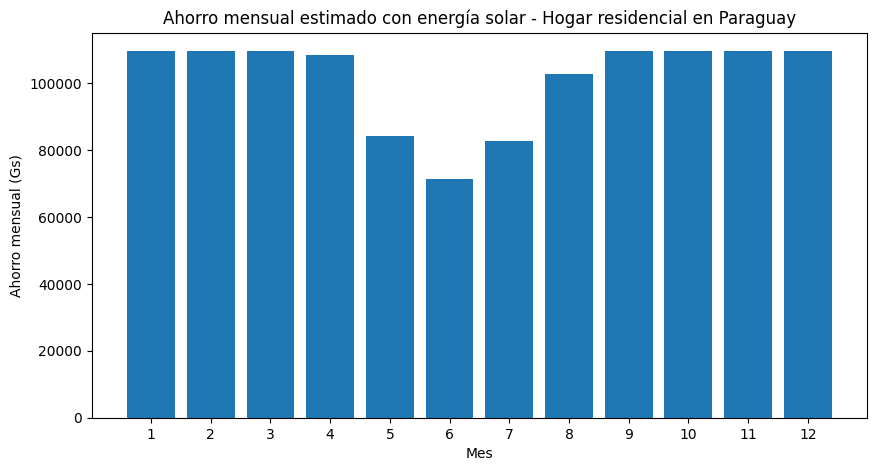

In [58]:


plt.figure(figsize=(10,5))
plt.bar(df_residencial["mes"], df_residencial["ahorro_gs"])

plt.title("Ahorro mensual estimado con energía solar - Hogar residencial en Paraguay")
plt.xlabel("Mes")
plt.ylabel("Ahorro mensual (Gs)")

plt.xticks(range(1, 13))
plt.savefig("images/ahorro_mensual.png", dpi=300, bbox_inches="tight")
plt.show()

El análisis del ahorro mensual muestra una clara variabilidad estacional, alineada con los patrones de radiación solar en Paraguay.

Los resultados indican que:

El ahorro máximo se alcanza entre los meses de octubre y marzo, superando los 100.000 Gs mensuales.
Durante los meses de invierno (mayo a julio), el ahorro disminuye, aunque sigue siendo significativo.

Esto evidencia que la implementación de sistemas fotovoltaicos residenciales en Paraguay puede generar ahorros económicos constantes durante todo el año, con mayor eficiencia en los meses de mayor radiación solar.

In [59]:
#cobertura promedio
print("Cobertura promedio (%):", df_residencial["cobertura_pct"].mean())

Cobertura promedio (%): 113.07333333333334


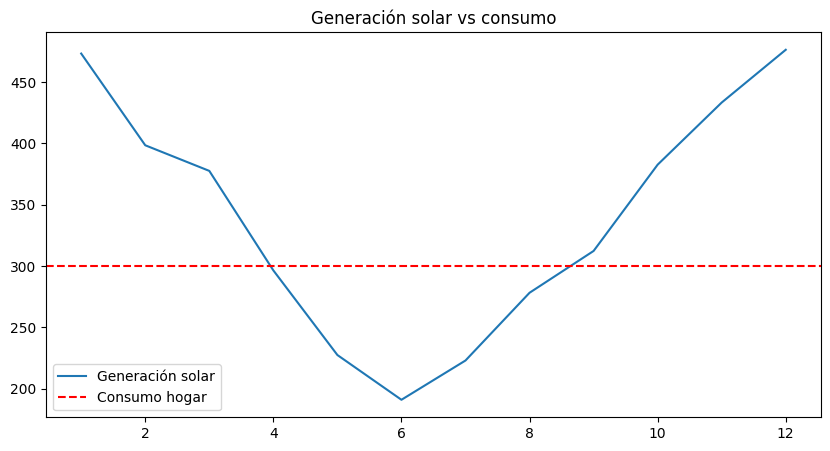

In [60]:
#grafico de comparación de consumo vs generación
plt.figure(figsize=(10,5))

plt.plot(df_residencial["mes"], df_residencial["generacion_kwh"], label="Generación solar")
plt.axhline(y=300, color='r', linestyle='--', label="Consumo hogar")

plt.legend()
plt.title("Generación solar vs consumo")
plt.savefig("images/generacion_vs_consumo.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusión

El sistema solar permite reducir significativamente el consumo eléctrico y generar ahorro económico.

El nivel de cobertura depende de la capacidad instalada y la radiación disponible.